# Data Pipeline untuk Analisis Transaksi E-Commerce

## Instalasi Package

In [2]:
# Install package dasar
!pip install pandas numpy matplotlib seaborn

# Install Kaggle API (untuk download dataset dari Kaggle)
#!pip install kaggle

# Install library tambahan (jika diperlukan)
#!pip install openpyxl sqlalchemy kagglehub
!pip install kagglehub


# 1. Extract

#### Inisialisasi

In [3]:
import kagglehub
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

C:\Users\Rozan\anaconda3\envs\data_analyst\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Input Data

In [51]:
# Step 1: Download ke cache kagglehub
cache_path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

# Step 2: Tentukan folder tujuan (relatif terhadap notebook: ../data/...)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))  # naik 1 level dari /notebooks
project_data_path = os.path.join(project_root, "data", "brazilian-ecommerce")
os.makedirs(project_data_path, exist_ok=True)

# Step 3: Salin file dari cache ke folder project/data/
for filename in os.listdir(cache_path):
    src = os.path.join(cache_path, filename)
    dst = os.path.join(project_data_path, filename)
    shutil.copy2(src, dst)

print("Dataset berhasil dipindahkan ke:", project_data_path)

# Step 4: Simpan path untuk akses data selanjutnya
path = project_data_path

Dataset berhasil dipindahkan ke: C:\Users\Rozan\OneDrive\Documents\Developments\Python\Data Analyst\Data-Pipeline-untuk-Analisis-Transaksi-E-Commerce\data\brazilian-ecommerce


 #### Data Scheme
 Schema data ini menunjukan relasi dari data yang ada untuk digunakan sebagai panduan untuk menggabungkan data.
 <img src="https://i.imgur.com/HRhd2Y0.png" alt="data-scheme" width="1000"/>


In [52]:
"""
# Contoh: Baca file orders
orders_path = os.path.join(path, "olist_orders_dataset.csv")
orders_df = pd.read_csv(orders_path)

# Contoh: Baca file products
products_path = os.path.join(path, "olist_products_dataset.csv")
products_df = pd.read_csv(products_path)

print("Orders Data:")
print(orders_df.head())
"""

'\n# Contoh: Baca file orders\norders_path = os.path.join(path, "olist_orders_dataset.csv")\norders_df = pd.read_csv(orders_path)\n\n# Contoh: Baca file products\nproducts_path = os.path.join(path, "olist_products_dataset.csv")\nproducts_df = pd.read_csv(products_path)\n\nprint("Orders Data:")\nprint(orders_df.head())\n'

In [53]:
# List semua file CSV
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

# Baca semua CSV ke dictionary of DataFrames
dataframes = {}
for file in csv_files:
    df_name = file.replace("olist_", "").replace("_dataset.csv", "")
    dataframes[df_name] = pd.read_csv(os.path.join(path, file))

# 2. Transform

#### Mengetahui kata kunci data

In [54]:
for key in dataframes:
    print(key)

customers
geolocation
orders
order_items
order_payments
order_reviews
products
sellers
product_category_name_translation.csv


#### Rename dan Akses data utama

In [55]:
# Contoh: Ambil data orders dan customers
customers = dataframes['customers']
geolocation = dataframes['geolocation']
orders = dataframes['orders']
order_items = dataframes['order_items']
order_payments = dataframes['order_payments']
order_reviews = dataframes['order_reviews']
products = dataframes['products']
sellers = dataframes['sellers']
product_category_name = dataframes['product_category_name_translation.csv']

Mengetahui seperti apa data dari order:

In [56]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


#### Menggabungkan data

In [57]:
# Menggabungkan dataset order dengan customer
merged_data = pd.merge(orders, customers, on="customer_id", how="left")

# Menggabungkan dataset order dengan items
merged_data = pd.merge(merged_data, orders, on="order_id", how="inner")

merged_data = pd.merge(merged_data, order_items, on="order_id", how="inner")

# Menggabungkan dataset items dengan products
merged_data = pd.merge(merged_data, products, on="product_id", how="left")

# Menggabungkan dataset items dengan sellers
merged_data = pd.merge(merged_data, sellers, on="seller_id", how="left")

# Menggabungkan dataset orders dengan payments
merged_data = pd.merge(merged_data, order_payments, on="order_id", how="left")

# Menggabungkan dataset orders dengan reviews
merged_data = pd.merge(merged_data, order_reviews, on="order_id", how="left")


In [58]:
merged_data.head()

,order_id,customer_id_x,order_status_x,order_purchase_timestamp_x,order_approved_at_x,order_delivered_carrier_date_x,order_delivered_customer_date_x,order_estimated_delivery_date_x,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58


## 2.1 Analisis Penjualan Bulanan

#### Hitung Penjualan Bulanan dan Identifikasi Bulan Tertinggi/Rendah
Menghitung penjualan bulanan bertujuan untuk mengetahui kapan penjualan paling tinggi dan paling rendah revenunya berdasarkan per bulannya

In [59]:
# Melihat column apa saja yang ada pada order data
list(orders.columns)

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

In [60]:
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [61]:
def calculate_order(orders_data, orders_item_data, times='M'):
    # Menggabungkan (merge) dataset order_items dengan orders berdasarkan kolom "order_id".
    # Menggunakan inner join, sehingga hanya baris yang memiliki "order_id" yang sama di kedua dataset yang akan dipertahankan.
    merged_data = pd.merge(orders_item_data, orders_data, on="order_id", how="inner")
    
    # Mengonversi kolom 'order_purchase_timestamp' menjadi format datetime.
    # Parameter errors='coerce' akan mengubah nilai yang tidak bisa dikonversi menjadi NaT (Not a Time).
    merged_data['order_purchase_timestamp'] = pd.to_datetime(merged_data['order_purchase_timestamp'], errors='coerce')
    
    # Menghapus baris-baris yang memiliki nilai kosong (missing values) pada kolom 'order_purchase_timestamp' dan 'price'.
    # Hal ini penting agar perhitungan penjualan tidak terganggu oleh data yang tidak lengkap.
    merged_data = merged_data.dropna(subset=['order_purchase_timestamp', 'price'])
    
    # Mengonversi kolom 'price' menjadi tipe numerik agar operasi matematis (penjumlahan) dapat dilakukan.
    # Jika ada nilai yang tidak bisa dikonversi, akan diubah menjadi NaN.
    merged_data['price'] = pd.to_numeric(merged_data['price'], errors='coerce')
    
    # Menghapus baris yang memiliki nilai NaN pada kolom 'price' setelah konversi.
    merged_data = merged_data.dropna(subset=['price'])
    
    # Membuat kolom baru 'purchase_month' dengan mengekstrak periode bulanan dari kolom 'order_purchase_timestamp'.
    # Hasilnya adalah periode dalam format 'YYYY-MM', misalnya "2017-10".
    merged_data['purchase_month'] = merged_data['order_purchase_timestamp'].dt.to_period('M')
    
    # Mengelompokkan data berdasarkan 'purchase_month' dan menghitung total penjualan (sum) pada kolom 'price'
    # untuk setiap bulan.
    monthly_sales = merged_data.groupby('purchase_month')['price'].sum()
    
    # Mengembalikan hasil agregasi total penjualan per bulan.
    return monthly_sales

monthly_sales_order = calculate_order(orders, order_items)

# Identifikasi bulan dengan penjualan maksimum dan minimum
max_month = monthly_sales_order.idxmax()
min_month = monthly_sales_order.idxmin()

print(f"Bulan penjualan tertinggi: {max_month}, penjualan: {monthly_sales_order[max_month]}")
print(f"Bulan penjualan terendah: {min_month}, penjualan: {monthly_sales_order[min_month]}")

Bulan penjualan tertinggi: 2017-11, penjualan: 1010271.37
Bulan penjualan terendah: 2016-12, penjualan: 10.9


## 2.2 Visualisasi Penjualan Bulanan

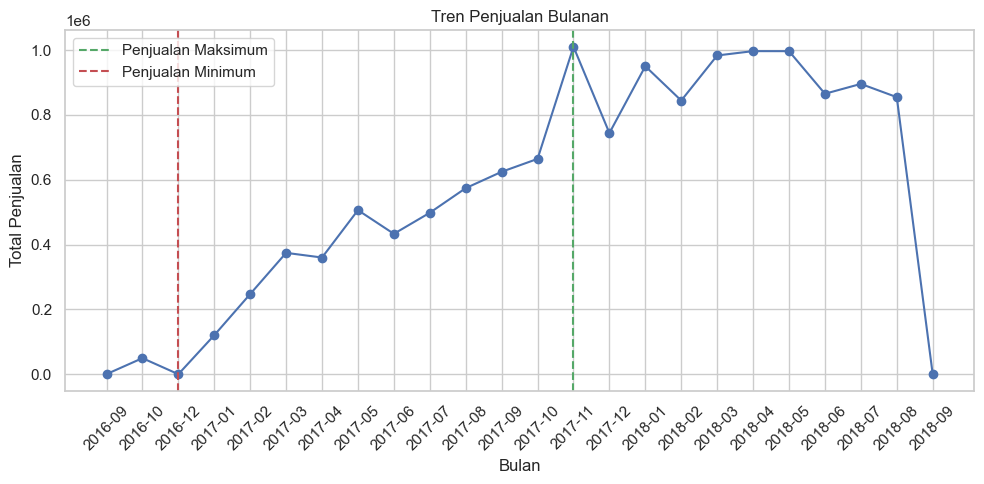

In [62]:
# Visualisasi grafik tren penjualan bulanan
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales_order.index.astype(str), monthly_sales_order.values, marker='o')
plt.title('Tren Penjualan Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Penjualan')
plt.xticks(rotation=45)
plt.axvline(x=str(max_month), color='g', linestyle='--', label='Penjualan Maksimum')
plt.axvline(x=str(min_month), color='r', linestyle='--', label='Penjualan Minimum')
plt.legend()
plt.tight_layout()
# Simpan ke file sebelum show
plt.savefig("../visualizations/monthly_sales_trend.png", dpi=300)
plt.show()



## 2.3 Analisis Penjualan Berdasarkan Kategori Produk

In [63]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [64]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


#### Reveneu

In [65]:
# Menggabungkan dataset orders dengan order items
merged_data_order = pd.merge(orders, order_items, on="order_id", how="inner")

# Menggabungkan dataset items dengan products
merged_data_products = pd.merge(merged_data_order, products, on="product_id", how="left")

In [66]:
merged_data_products.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm'],
      dtype='object')

In [67]:
# Agregasi total penjualan berdasarkan kategori produk
category_sales = merged_data_products.groupby('product_category_name')['price'].sum().reset_index()

# Tampilkan hasil
print(category_sales)

        product_category_name      price
0   agro_industria_e_comercio   72530.47
1                   alimentos   29393.41
2           alimentos_bebidas   15179.48
3                       artes   24202.64
4          artes_e_artesanato    1814.01
..                        ...        ...
68    sinalizacao_e_seguranca   21509.23
69   tablets_impressao_imagem    7528.41
70                  telefonia  323667.53
71             telefonia_fixa   59583.00
72      utilidades_domesticas  632248.66

[73 rows x 2 columns]


C:\Users\Rozan\AppData\Local\Temp\ipykernel_25132\2698967733.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price', y='product_category_name', data=category_sales, palette='viridis')


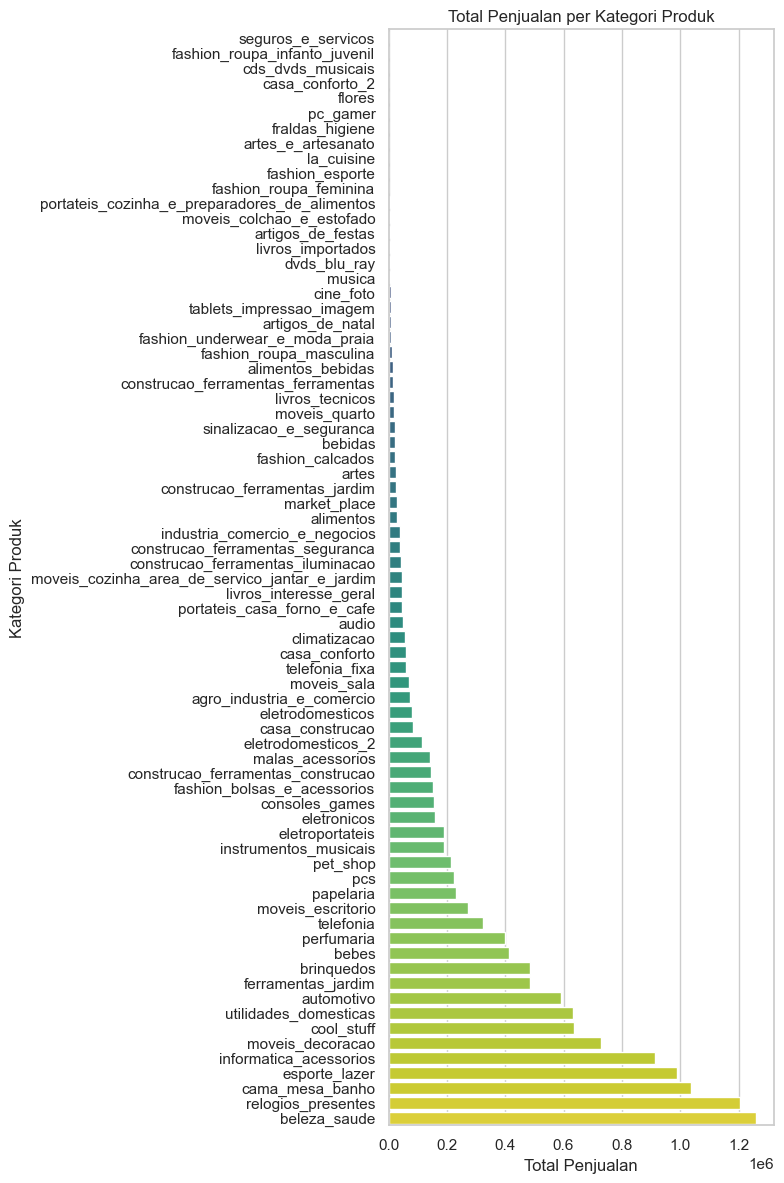

In [68]:
# Asumsi 'category_sales' sudah berisi kolom:
# 1) 'product_category_name' 
# 2) 'price' (total penjualan per kategori)

# (Opsional) Sorting kategori dari penjualan terbesar ke terkecil
category_sales = category_sales.sort_values('price', ascending=True)

# Visualisasi
plt.figure(figsize=(8, 12))
sns.barplot(x='price', y='product_category_name', data=category_sales, palette='viridis')
plt.title('Total Penjualan per Kategori Produk')
plt.xlabel('Total Penjualan')
plt.ylabel('Kategori Produk')
plt.tight_layout()
# Simpan ke file sebelum show
plt.savefig("../visualizations/total_penjualan_per_kategori.png", dpi=300)
plt.show()

## 2.4 Analisis Penjualan Berdasarkan Kategori Produk

     product_category_name  items_count
13         cama_mesa_banho        11115
11            beleza_saude         9670
32           esporte_lazer         8641
54        moveis_decoracao         8334
44  informatica_acessorios         7827


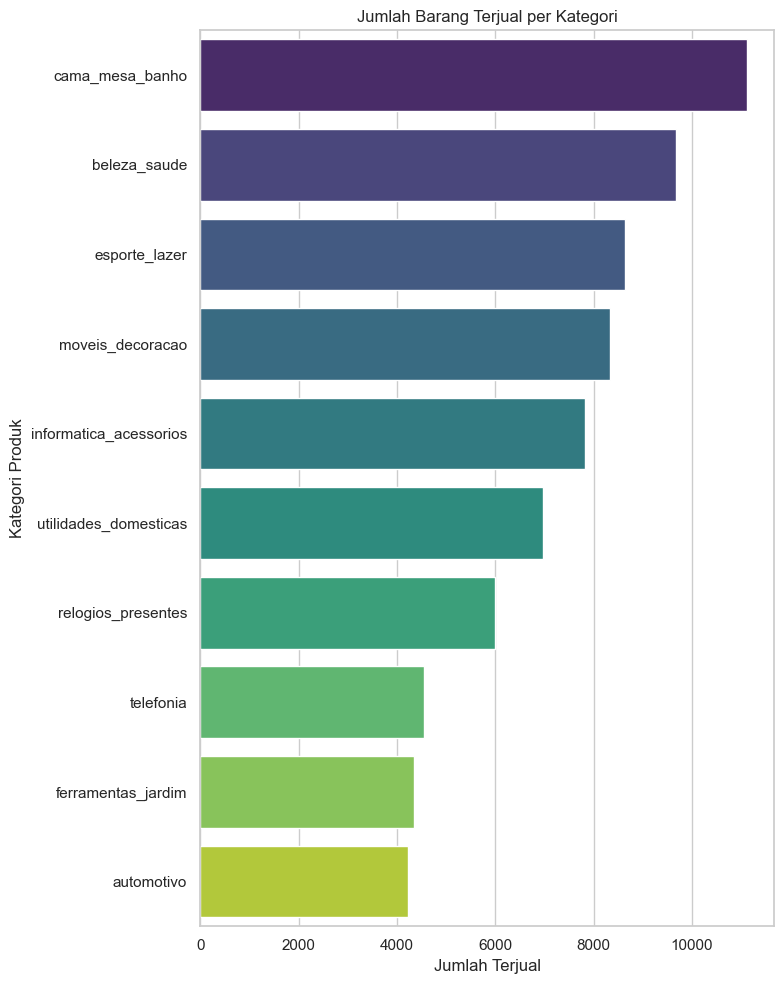

In [69]:
# Setiap baris mewakili 1 item, jadi kita cukup count
items_sold = merged_data_products.groupby('product_category_name')['order_item_id'].count().reset_index()
items_sold.rename(columns={'order_item_id': 'items_count'}, inplace=True)
items_sold = items_sold.sort_values('items_count', ascending=False)

print(items_sold.head())  # Melihat 5 kategori dengan jumlah item terbanyak

plt.figure(figsize=(8, 10))
# Gunakan 'product_category_name' juga sebagai hue dan matikan dodge agar bar tidak terpisah
ax = sns.barplot(
    x='items_count',
    y='product_category_name',
    hue='product_category_name',
    data=items_sold.head(10),
    palette='viridis',
    dodge=False
)

# Hilangkan legend agar tampilannya seperti sebelum ada hue
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.title('Jumlah Barang Terjual per Kategori')
plt.xlabel('Jumlah Terjual')
plt.ylabel('Kategori Produk')
plt.tight_layout()
plt.savefig("../visualizations/jumlah_barang_terjual_per_kategori.png", dpi=300)
plt.show()

## 2.5 Analisis Laba Bulanan

In [70]:
merged_data.columns

Index(['order_id', 'customer_id_x', 'order_status_x',
       'order_purchase_timestamp_x', 'order_approved_at_x',
       'order_delivered_carrier_date_x', 'order_delivered_customer_date_x',
       'order_estimated_delivery_date_x', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'customer_id_y', 'order_status_y', 'order_purchase_timestamp_y',
       'order_approved_at_y', 'order_delivered_carrier_date_y',
       'order_delivered_customer_date_y', 'order_estimated_delivery_date_y',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 're

In [71]:
# Misal merged_data sudah memiliki kolom 'price' dan 'freight_value'
merged_data['order_purchase_timestamp_x'] = pd.to_datetime(merged_data['order_purchase_timestamp_x'], errors='coerce')
merged_data['purchase_month'] = merged_data['order_purchase_timestamp_x'].dt.to_period('M')

# Asumsi: payment_value mencakup biaya operasional atau total pembayaran yang diterima
monthly_revenue = merged_data.groupby('purchase_month')['price'].sum()
monthly_payment = merged_data.groupby('purchase_month')['payment_value'].sum()

# Definisikan laba (misalnya, margin = revenue - (payment_value - revenue) jika payment_value sudah mencakup markup)
monthly_profit = monthly_revenue - (monthly_payment - monthly_revenue)

# Identifikasi bulan dengan laba tertinggi dan terendah
max_profit_month = monthly_profit.idxmax()
min_profit_month = monthly_profit.idxmin()

print("Bulan laba tertinggi:", max_profit_month, "dengan laba:", monthly_profit[max_profit_month])
print("Bulan laba terendah:", min_profit_month, "dengan laba:", monthly_profit[min_profit_month])

Bulan laba tertinggi: 2018-03 dengan laba: 576955.25
Bulan laba terendah: 2016-12 dengan laba: 2.1799999999999997


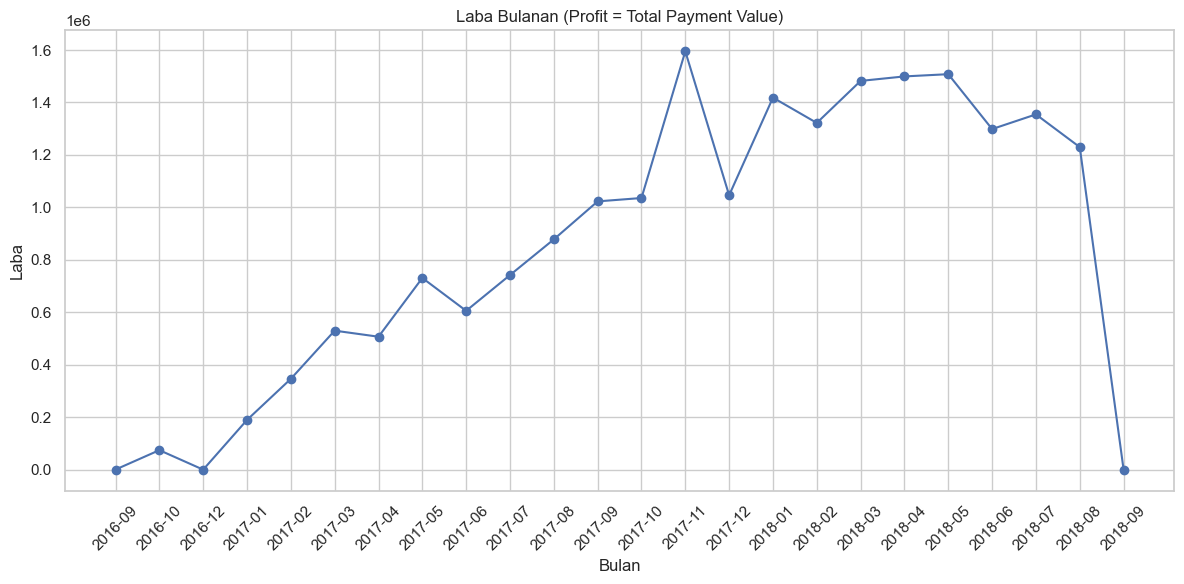

In [72]:
# Misalnya, merged_data sudah merupakan hasil merge dari berbagai dataset,
# dan kita menggunakan kolom 'order_purchase_timestamp_x' dan 'payment_value'.

# Konversi kolom timestamp ke datetime
merged_data['order_purchase_timestamp'] = pd.to_datetime(merged_data['order_purchase_timestamp_x'], errors='coerce')

# Hapus baris dengan nilai kosong pada kolom yang penting
merged_data = merged_data.dropna(subset=['order_purchase_timestamp', 'payment_value'])

# Pastikan kolom payment_value berupa numerik
merged_data['payment_value'] = pd.to_numeric(merged_data['payment_value'], errors='coerce')
merged_data = merged_data.dropna(subset=['payment_value'])

# Buat kolom periode bulanan
merged_data['purchase_month'] = merged_data['order_purchase_timestamp'].dt.to_period('M')

# Agregasi total payment_value per bulan (asumsi ini mewakili laba)
monthly_profit = merged_data.groupby('purchase_month')['payment_value'].sum()

# Plot grafik garis untuk menampilkan tren laba bulanan
plt.figure(figsize=(12, 6))
plt.plot(monthly_profit.index.astype(str), monthly_profit.values, marker='o', linestyle='-')
plt.title('Laba Bulanan (Profit = Total Payment Value)')
plt.xlabel('Bulan')
plt.ylabel('Laba')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visualizations/laba_bulanan.png", dpi=300)
plt.show()

# 3. Load

In [76]:
def load_data(monthly_sales_df):
    conn = sqlite3.connect('../ecommerce_analysis.db')
    monthly_sales_df.to_sql('monthly_sales', conn, if_exists='replace', index=False)
    conn.close()

# Misalnya, jika monthly_sales_df sudah disiapkan:
load_data(monthly_sales_order)
